# RQ2 - Does instruction type affect RAPL accuracy?
## Experiment E2 - Arrow Lake, instruction-set workload

Cells are **verbatim** from `pc2_instructiontype_expanded_withlogs.ipynb`.
See `../KNOWN_ISSUES.md`.

**Outputs:** `skesd_sample_pc2.pkl`, Kruskal/Dunn CSVs.

**Requires R** with `ScottKnottESD` plus `rpy2` - see `../ENVIRONMENT.md`.


## Data preparation


In [2]:
#this method is updated since Oct 21. A better implementation would be to skip the header, then use vectorized operation in numpy.
#binparserGraph
#binparserTemp
#temporary binary parser before we can get xml analysis working # NOT TEMPORARY ANYMORE...

import os
import struct
import pandas as pd
import numpy as np

def parse_payload(payload: bytes):
    # payload = 4B header + 8B timestamp + 70B data (14×5B entries)
    timestamp = struct.unpack('<Q', payload[4:12])[0]
    entries = payload[12:]
    data_dict = {}
    for i in range(0, len(entries), 5):
        char_id = chr(entries[i])
        value = struct.unpack('<f', entries[i+1:i+5])[0]
        data_dict[char_id] = value
    return timestamp, data_dict

def parse_binary_folder(folder_path: str):
    # 4-byte discard field, then 8-byte timestamp, then 16 × (1-byte id + 4-byte float)
    record_dtype = np.dtype([
        ('_discard', '4u1'),                 # 4 bytes
        ('timestamp', '<u8'),                # 8 bytes (uint64)
        ('pairs', [('id', 'u1'), ('data', '<f4')], (16,))  # 16 × (1+4)
    ])
    record_size = record_dtype.itemsize  # should be 92 bytes

    files = sorted(
        [f for f in os.listdir(folder_path) if f.startswith('data') and f.endswith('.bin')],
        key=lambda x: int(x[4:-4])
    )

    timestamps_all = []
    id_arrays = {i: [] for i in range(16)}  # accumulate data columns by slot
    id_chars = None                         # to hold column names (char IDs)

    for filename in files:
        path = os.path.join(folder_path, filename)

        with open(path, 'rb') as f:
            data_bytes = f.read()  # read entire file (no header)
            n_records = len(data_bytes) // record_size
            if n_records == 0:
                continue

            # vectorized read
            arr = np.frombuffer(data_bytes, dtype=record_dtype, count=n_records)

            timestamps = arr['timestamp']
            ids = arr['pairs']['id']       # shape (n_records, 16)
            vals = arr['pairs']['data']    # shape (n_records, 16)

            timestamps_all.append(timestamps)

            # verify consistent IDs per column
            first_ids = ids[0, :]
            if not np.all(ids == first_ids):
                mismatched = np.nonzero(~np.all(ids == first_ids, axis=1))[0][:5]
                print(f"\n[DEBUG] ID mismatch in file {filename}: showing first {len(mismatched)} bad rows")
                print("Expected IDs (bytes):", " ".join(f"{b:02X}" for b in first_ids))
                for idx in mismatched:
                    raw_hex = " ".join(f"{b:02X}" for b in ids[idx])
                    print(f"  Row {idx:>6}: {raw_hex}")
                raise ValueError(f"File {filename} has mixed IDs per column!")

            # store char representations once (from first file)
            if id_chars is None:
                id_chars = [chr(x) for x in first_ids]

            # accumulate per-ID arrays
            for i, id_val in enumerate(first_ids):
                id_arrays[i].append(vals[:, i])

    if not timestamps_all:
        raise ValueError("No valid records found in folder!")

    # concatenate across files
    timestamps_all = np.concatenate(timestamps_all)
    data_cols = {}
    for i, chunks in id_arrays.items():
        if len(chunks) == 0:
            continue
        colname = id_chars[i] if id_chars is not None else f"id_{i}"
        data_cols[colname] = np.concatenate(chunks)

    # Build DataFrame
    df = pd.DataFrame(data_cols)
    df.insert(0, "timestamp", timestamps_all.astype(np.uint64))

    return df

def find_rollovers(df):
    if df['timestamp'].dtype != 'uint64':
        df['timestamp'] = df['timestamp'].astype('uint64')

    # Diff using int64 to preserve exact rollover detection
    diffs = df['timestamp'].astype('int64').diff()

    rollover_points = df.index[diffs < 0].tolist()

    for idx in rollover_points:
        t_before = df.loc[idx - 1, 'timestamp']
        t_after = df.loc[idx, 'timestamp']
        print(f"Timestamp rollover at index {idx}: {t_before} → {t_after}")

    return rollover_points

# Example usage:
df = parse_binary_folder('../data/E2-arrowlake-instructions/teensy')
print(df.head(150))

print (df.iloc[12:75].head(10))

rollover = find_rollovers(df)
print(rollover)

print(df.shape)

corrected_df = df # this is just bandaid for things that still expect "corrected df"

          timestamp         A         B         C         D         H  \
0    11847837392042  2.024665  0.411796  2.196247  0.446113  2.756747   
1    11847837908042  2.058981  0.434674  2.230563  0.446113  2.676676   
2    11847838424042  2.058981  0.411796  2.207685  0.446113  2.733870   
3    11847838941042  2.001787  0.411796  2.196247  0.434674  2.699553   
4    11847839457042  2.024665  0.411796  2.196247  0.446113  2.756747   
..              ...       ...       ...       ...       ...       ...   
145  11847912366042  2.047543  0.411796  2.207685  0.434674  2.676676   
146  11847912883042  2.024665  0.388919  2.196247  0.434674  2.642359   
147  11847913399042  2.081859  0.411796  2.230563  0.446113  2.642359   
148  11847913916042  2.024665  0.411796  2.196247  0.434674  2.722431   
149  11847914432042  2.058981  0.411796  2.253441  0.434674  2.756747   

            I         J         K         Y         Z         O         P  \
0    1.086684  1.578552  0.320286  3.798809  3

In [3]:
#use this to read rapl if it's PKG, DRAM and PSYS
SAMP_PATH = "../data/E2-arrowlake-instructions/rapl"

import os
import glob
import numpy as np
import pandas as pd
import struct

import os
import glob
import numpy as np
import pandas as pd

def read_rapl_binaries(SAMP_PATH):
    """
    Reads all binary files written by flush_to_file() in C:
        fwrite(ts_buf, sizeof(int64_t), BUF_SIZE, f);
        fwrite(e_buf, sizeof(float),   BUF_SIZE, f);

    Each file contains two contiguous arrays:
        - timestamps (int64 nanoseconds)
        - energy samples (float32 joules)
    Returns a pandas DataFrame with columns ['timestamp_ns', 'energy'].
    """

    # Match pattern like rapl_YYYYMMDD_HHMMSS_###.bin
    files = sorted(glob.glob(os.path.join(SAMP_PATH, "rapl_????????_??????_???.bin")))
    if not files:
        raise FileNotFoundError(f"No RAPL binary files found in {SAMP_PATH}")

    dfs = []
    for fname in files:
        with open(fname, "rb") as f:
            raw = f.read()

        # Each file contains BUF_SIZE timestamps (8 bytes each) + BUF_SIZE floats (4 bytes each) *3
        # So total length must be divisible by 20
        if len(raw) % 20 != 0:
            raise ValueError(f"File {fname} length {len(raw)} not multiple of 20 bytes")

        # Determine number of samples
        total_bytes = len(raw)
        n_samples = total_bytes // 20

        # Split manually
        ts_bytes = raw[:n_samples * 8]
        pkg_bytes = raw[n_samples * 8 : n_samples * 12]
        dram_bytes  =  raw[n_samples * 12 : n_samples * 16 ]
        psys_bytes  = raw[n_samples * 16:]

        timestamps = np.frombuffer(ts_bytes, dtype="<u8")  # little-endian int64
        energy_pkg     = np.frombuffer(pkg_bytes,  dtype="<f4")  # little-endian float32
        energy_dram     = np.frombuffer(dram_bytes,  dtype="<f4")  # little-endian float32
        energy_psys     = np.frombuffer(psys_bytes,  dtype="<f4")  # little-endian float32


        if len(timestamps) != len(energy_pkg):
            raise ValueError(f"Timestamp and energy count mismatch in {fname}")

        df = pd.DataFrame({
            "timestamp": timestamps,
            "energy_pkg" : energy_pkg,
            "energy_dram" : energy_dram,
            "energy_psys" : energy_psys,
        })
        df["energy"] = df["energy_pkg"]
        dfs.append(df)

    # Combine all
    df_all = pd.concat(dfs, ignore_index=True)
    return df_all

df_rapl = read_rapl_binaries(SAMP_PATH)
print(df_rapl.head(10))
print(df_rapl.shape)

        timestamp  energy_pkg  energy_dram  energy_psys    energy
0  11817130729721    0.057922          0.0          0.0  0.057922
1  11817131676212    0.000000          0.0          0.0  0.000000
2  11817132610181    0.029358          0.0          0.0  0.029358
3  11817133744396    0.024231          0.0          0.0  0.024231
4  11817134633226    0.022339          0.0          0.0  0.022339
5  11817135717780    0.000000          0.0          0.0  0.000000
6  11817136767095    0.026672          0.0          0.0  0.026672
7  11817137747185    0.023315          0.0          0.0  0.023315
8  11817138728442    0.000000          0.0          0.0  0.000000
9  11817139725948    0.021240          0.0          0.0  0.021240
(500000, 5)


Index(['timestamp', 'energy_pkg', 'energy_dram', 'energy_psys', 'energy'], dtype='object')
2.7311633
262143.98
outliers:
             timestamp     energy_pkg  energy_dram  energy_psys         energy
22459   11839590645947  262143.984375          0.0          0.0  262143.984375
454034  12271165547517  262143.984375          0.0          0.0  262143.984375
470422  12287553537995  262143.968750          0.0          0.0  262143.968750
478607  12295738539616  262143.984375          0.0          0.0  262143.984375
494996  12312127540119  262143.968750          0.0          0.0  262143.968750
pruned 5 outliers
0.10972344
(499995, 5)
12317129522930
11817130729721
12067128535875.49
outliers:
Empty DataFrame
Columns: [timestamp, energy_pkg, energy_dram, energy_psys, energy]
Index: []
pruned 0 outliers
12067128535875.49
(499995, 5)
Found these rows duplicated observations.
             timestamp  energy_pkg  energy_dram  energy_psys    energy
12460   11829590538050    0.000000          0.0     

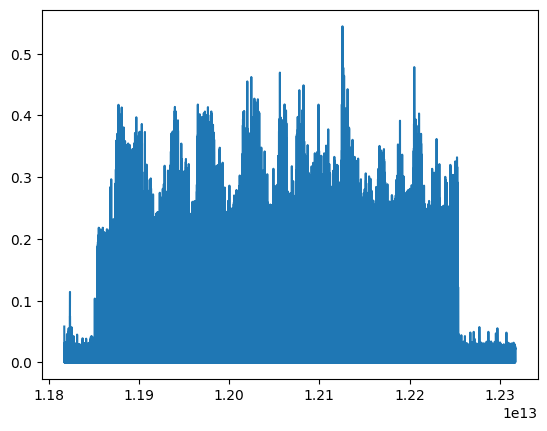

In [4]:
# data cleaning steps for RAPL
# prune outliers that look like 262143.968750, cause is unclear.
print(df_rapl.columns)
print(df_rapl["energy_pkg"].mean())
print(df_rapl["energy_pkg"].max())

df_outliers = df_rapl[df_rapl["energy_pkg"] > 200000]
print("outliers:")
print(df_outliers)

df_temp2 = df_rapl[df_rapl["energy_pkg"] < 200000]
print(f"pruned {len(df_rapl) - len(df_temp2)} outliers")
print(df_temp2["energy_pkg"].mean())
print(df_temp2.shape)

df_rapl=df_temp2

print(df_rapl["timestamp"].max())
print(df_rapl["timestamp"].min())
print(df_rapl["timestamp"].mean())

df_outliers = df_rapl[df_rapl["timestamp"] == 0]
print("outliers:")
print(df_outliers)

df_temp3 = df_rapl[df_rapl["timestamp"] != 0]
print(f"pruned {len(df_rapl) - len(df_temp3)} outliers")
print(df_temp3["timestamp"].mean())
print(df_temp3.shape)
df_rapl = df_temp3


duplicated_rows_df = df_rapl[df_rapl.duplicated(subset = ["timestamp"], keep = False)]
duplicated_rows_df = duplicated_rows_df.sort_values(by="timestamp")
print("Found these rows duplicated observations.")
print(duplicated_rows_df)
df_temp4 = df_rapl.drop_duplicates(subset=["timestamp"], keep= 'first')
print(f"dropping {len(df_rapl) - len(df_temp4)} duplicated rows")
df_rapl = df_temp4

import matplotlib.pyplot as plt
plt.plot(df_rapl["timestamp"].values,df_rapl["energy_pkg"].values)
plt.show()

In [5]:
def compute_power_from_energy(df: pd.DataFrame,
                              time_col: str = "timestamp",
                              energy_col: str = "energy") -> pd.DataFrame:
    """
    Compute instantaneous power (Watts) from cumulative energy (Joules)
    using timestamp differences in nanoseconds.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing 'timestamp' (ns) and 'energy' (Joule).
    time_col : str, default 'timestamp'
        Column name for timestamp (in nanoseconds).
    energy_col : str, default 'energy'
        Column name for cumulative energy (in Joules).

    Returns
    -------
    pd.DataFrame
        Copy of df with a new 'power' column (float32, in Watts).
    """
    result = df.copy()

    # Compute differences
    dE = result[energy_col]        # ΔEnergy (J)
    dT_ns = result[time_col].diff()        # ΔTime (ns)
    
    # Avoid divide-by-zero or negative intervals
    dT_ns = dT_ns.replace(0, np.nan)

    # Convert ns → seconds and compute power (Watts = J / s)
    result["power"] = (dE / (dT_ns * 1e-9)).astype("float32")

    return result

df_rapl_watt = compute_power_from_energy(df_rapl).dropna()
df_rapl_watt["dram_rapl"] = compute_power_from_energy(df_rapl, energy_col="energy_dram").dropna()["power"]
print(df_rapl_watt.shape)
print(df_rapl_watt.head(5))

(499987, 7)
        timestamp  energy_pkg  energy_dram  energy_psys    energy      power  \
1  11817131676212    0.000000          0.0          0.0  0.000000   0.000000   
2  11817132610181    0.029358          0.0          0.0  0.029358  31.433495   
3  11817133744396    0.024231          0.0          0.0  0.024231  21.363636   
4  11817134633226    0.022339          0.0          0.0  0.022339  25.132891   
5  11817135717780    0.000000          0.0          0.0  0.000000   0.000000   

   dram_rapl  
1        0.0  
2        0.0  
3        0.0  
4        0.0  
5        0.0  


In [ ]:
# --- Trim both streams to the start of the first workload --------------------
# REPLACEMENT CELL - this is the one cell in the package that is not verbatim.
#
# The original cell 6 here subtracted a hardcoded 8,642,644,546,100 ns from the
# RAPL timestamps. That constant does not belong to this capture: applied here it
# moves RAPL to 3.17e12-3.67e12 ns against a sensor span of 11.85e12-12.32e12 ns,
# leaving the two streams with no overlap at all. The bracket merge then returns
# an empty frame and the notebook dies on the next cell with KeyError: 'Y_2'.
# See KNOWN_ISSUES.md, K3, for the evidence.
#
# No shift is applied in its place, because none is needed: on this capture the
# two streams already agree to sub-millisecond. The bracket merge matches 438,241
# of 499,993 RAPL samples inside its 500 us tolerance, which is exactly the row
# count recorded in the original notebook's own stored output.
#
# What this cell does instead is give both raw streams a common origin, by
# trimming each to start at the first workload boundary in runinfo.pkl.

# `pickle` is needed below. `scipy` is imported here too because the cells that
# originally bound it are not all present in every selection - see K9. Neither
# import changes any value; they only stop a NameError partway down.
import pickle

import scipy
import scipy.integrate
import scipy.stats

with open("../data/E2-arrowlake-instructions/runinfo.pkl", "rb") as _f:
    _workloads = pickle.load(_f)
WORKLOAD_START = _workloads[0]["start_ns"]

_n_rapl, _n_sensor = len(df_rapl_watt), len(corrected_df)
df_rapl_watt = df_rapl_watt[df_rapl_watt["timestamp"] >= WORKLOAD_START].reset_index(drop=True)
corrected_df = corrected_df[corrected_df["timestamp"] >= WORKLOAD_START].reset_index(drop=True)

print("trimmed to first workload start: {:,}".format(WORKLOAD_START))
print("  RAPL   {:,} -> {:,} rows".format(_n_rapl, len(df_rapl_watt)))
print("  sensor {:,} -> {:,} rows".format(_n_sensor, len(corrected_df)))
print("  RAPL   now spans {:,} .. {:,}".format(
    int(df_rapl_watt["timestamp"].min()), int(df_rapl_watt["timestamp"].max())))
print("  sensor now spans {:,} .. {:,}".format(
    int(corrected_df["timestamp"].min()), int(corrected_df["timestamp"].max())))


## Energy analysis: RAPL vs sensor per 100 ms window


[{'name': 'w1:fp64:idle', 'start_wall': '2026-05-05 19:04:12', 'start_ns': 11854073309704, 'end_wall': '2026-05-05 19:04:22', 'end_ns': 11864079625096, 'duration': 10.00626910199935, 'command': './code/combine_instruction --cores 20 --workload1 fp64 --workload2 idle --duration 10'}, {'name': 'w1:fp64:idle', 'start_wall': '2026-05-05 19:04:22', 'start_ns': 11864079794688, 'end_wall': '2026-05-05 19:04:32', 'end_ns': 11874085526834, 'duration': 10.005680668999048, 'command': './code/combine_instruction --cores 20 --workload1 fp64 --workload2 idle --duration 10'}, {'name': 'w1:int128:idle', 'start_wall': '2026-05-05 19:04:32', 'start_ns': 11874085727623, 'end_wall': '2026-05-05 19:04:42', 'end_ns': 11884091298049, 'duration': 10.005530438998903, 'command': './code/combine_instruction --cores 20 --workload1 int128 --workload2 idle --duration 10'}, {'name': 'w1:int32:idle', 'start_wall': '2026-05-05 19:04:42', 'start_ns': 11884091448086, 'end_wall': '2026-05-05 19:04:52', 'end_ns': 11894096

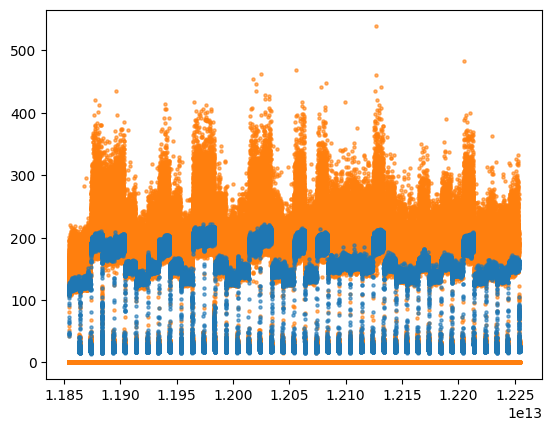

In [11]:
# this section intends to use a jumping window to split the observation into sections where we can observe if the sections are uniform.

# experiment info
with open('../data/E2-arrowlake-instructions/runinfo.pkl', "rb") as file: 
    workloads = pickle.load(file)
print(workloads)

workload_start = workloads[0]["start_ns"]
workload_end = workloads[-1]["end_ns"]

print(f"experiment duration: {workload_start} to {workload_end}, lasted {(workload_end - workload_start)/1000_000_000} s")


df_teensy_original = corrected_df
df_teensy_original["cpu_total"] = df_teensy_original["Y"] + df_teensy_original["Z"] + df_teensy_original["U"] + df_teensy_original["V"]
df_rapl_original = df_rapl_watt
print(df_teensy_original.columns) 
print(df_teensy_original.shape)
print(df_rapl_original.columns) 
print(df_rapl_original.shape)

df_teensy_1 = df_teensy_original.set_index("timestamp")
df_rapl_1 = df_rapl_original.set_index("timestamp")
df_merged_outer = pd.merge(df_teensy_1, df_rapl_1, left_index=True, right_index=True, how='outer')
print(df_merged_outer.head())

df_merged_outer = df_merged_outer[(df_merged_outer.index >= workload_start) & (df_merged_outer.index <= workload_end)]

# 1. Create a mask and Group IDs
is_not_nan = df_merged_outer['power'].notna()
group_id = is_not_nan.cumsum()

# 2. Count how many NaNs are in each group
# We only group the rows where 'a' was actually NaN
nan_counts = df_merged_outer[df_merged_outer['power'].isna()].groupby(group_id).size()

# 3. Include the "Zeroes"
# Some non-NaN values might have 0 NaNs following them.
# We reindex to include every group ID from 1 to the total count of non-NaNs.
total_non_nans = is_not_nan.sum()
all_gaps = nan_counts.reindex(np.arange(1, total_non_nans + 1), fill_value=0)

# 4. Final Statistics
stats = {
    'mean': all_gaps.mean(),
    'median': all_gaps.median(),
    'max': all_gaps.max(),
    'min': all_gaps.min()
}

print(stats)
all_gaps = all_gaps.sort_values(ascending = False)
#print(all_gaps.head())
plt.scatter(df_merged_outer.index, df_merged_outer["power"], s=5, color='tab:orange', alpha=0.6, label="rapl")
plt.scatter(df_merged_outer.index, df_merged_outer["cpu_total"], s=5, color='tab:blue', alpha=0.6, label="measured")
plt.show()


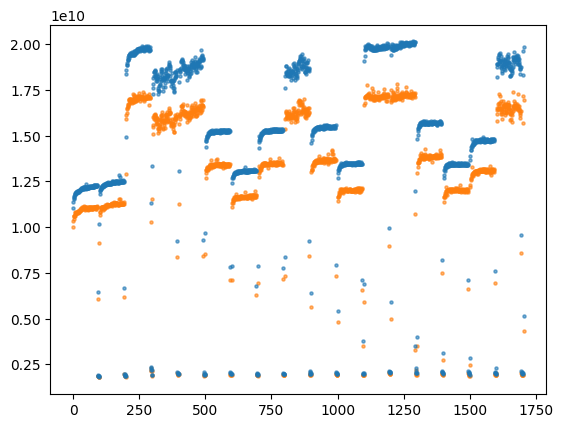

In [12]:
import pandas as pd
import numpy as np
from scipy.integrate import trapezoid

def integrate_dual_cadence(df, col1, col2, window = 10):
    # 1. Identify rows where 'a' is valid
    is_a_valid = df[col1].notna()
    
    # 2. Create Window IDs based on every 10 valid 'a' values
    # cumsum increments at every valid 'a', then // 10 groups them
    # We subtract 1 so the first group is 0
    a_group_id = (is_a_valid.cumsum() - 1) // window
    
    # 3. Handle Column B's range:
    # Column B needs to integrate everything from the first valid 'a' in the group
    # to just before the first 'a' of the NEXT group.
    # a_group_id naturally covers this range for every row.
    
    # 4. Define the integration logic
    def perform_integration(group):
        # -- Integration for A --
        # Filter only non-NaN a values
        a_data = group[col1].dropna()
        # Trapezoid needs at least 2 points to calculate area
        area_a = scipy.integrate.trapezoid(y=a_data.values, x=a_data.index, dx=1.0, axis=-1) if len(a_data) > 1 else 0
        
        # -- Integration for B --
        # Filter only non-NaN b values
        # This takes all rows in the 10-point 'a' window
        b_data = group[col2].dropna()
        area_b = scipy.integrate.trapezoid(y=b_data.values, x=b_data.index, dx=1.0, axis=-1) if len(b_data) > 1 else 0
        # print(a_data.index)
        # print(len(a_data.index))
        # print(b_data.index)
        # print(len(b_data.index))
        # print("break")

        return pd.Series({'area_a': area_a, 'area_b': area_b})

    # 5. Execute GroupBy
    # We only process groups where a_group_id >= 0 (ignores NaNs at the very start)
    results_df = df[a_group_id >= 0].groupby(a_group_id).apply(perform_integration)
    
    return results_df

# Example usage with dummy data
# df = pd.DataFrame({'a': [...], 'b': [...]})
integrated_results = integrate_dual_cadence(df_merged_outer.head(500000), "power", "cpu_total", window=100)

plt.scatter(integrated_results.index, integrated_results["area_a"], s=5, color='tab:orange', alpha=0.6, label="power (W)")
plt.scatter(integrated_results.index, integrated_results["area_b"], s=5, color='tab:blue', alpha=0.6, label="CPU Total (W)")
plt.show()

### Per-instruction-set energy samples


In [13]:
with open('../data/E2-arrowlake-instructions/runinfo.pkl', "rb") as file: 
    workloads = pickle.load(file)
#print(workloads)

samples_kw = []
for workload in workloads: 
    start_ns = workload["start_ns"]
    end_ns = workload["end_ns"]
    workload_name = workload["name"]
    samples_kw.append(df_merged_outer[(df_merged_outer.index > start_ns) & (df_merged_outer.index < end_ns)])

samples_integrals_kw = []
for sample in samples_kw: 
    samples_integrals_kw.append(integrate_dual_cadence(sample, "power", "cpu_total", window=100))

# for i, sample in enumerate(samples):
#     plt.scatter(samples_integrals[i].index, samples_integrals[i]["area_a"], s=5, color='tab:orange', alpha=0.6, label="power (W)")
#     plt.scatter(samples_integrals[i].index, samples_integrals[i]["area_b"], s=5, color='tab:blue', alpha=0.6, label="CPU Total (W)")
#     plt.show()

samples_by_workload_kw = {}
for i, workload in enumerate(workloads):
    if workload["name"] in samples_by_workload_kw.keys():
        df1 = samples_by_workload_kw[workload["name"]]
        df2 = samples_integrals_kw[i]
        samples_by_workload_kw[workload["name"]] = pd.concat([df1, df2], axis =0)
    else: 
        samples_by_workload_kw[workload["name"]] = samples_integrals_kw[i]
    # print(workload["name"])
    # print(samples_by_workload_kw[workload["name"]].shape)
    
for i, workload in enumerate(workloads):
    df1 = samples_by_workload_kw[workload["name"]]
    df1["diff"] = df1["area_a"] - df1["area_b"]
    df1["diff_normalized"] = df1["diff"] / df1["area_b"]

for i, sample in enumerate(list(samples_by_workload_kw.values())):
    print(type(sample))
    # plt.scatter(sample.index, sample["area_a"], s=5, color='tab:orange', alpha=0.6, label="power (W)")
    # plt.scatter(sample.index, sample["area_b"], s=5, color='tab:blue', alpha=0.6, label="CPU Total (W)")
    # plt.scatter(sample.index, sample["diff"], s=5, color='tab:green', alpha=0.6, label="diff")
    # plt.scatter(sample.index, sample["diff_normalized"], s=5, color='tab:red', alpha=0.6, label="diff normals")
    # plt.show()
    

    

#segments = [17398106102790, 17408115632950, 17418125344082, 17428134473623, 17438142474785, 17448150626666, 17458160825127, 17468168994269, 17478177946304,17488185946880, 17498193747238]

# plot_cpu_vs_energy(rapl_teensy_merged, sample_factor=100, time_col="timestamp", segments=segments)
# for i, workload in enumerate(workloads):
#     print(f"#{i}: {workload['name']}")



<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>


## RQ2: Kruskal-Wallis + Dunn post-hoc


2159.4429458929717
0.0
group
0    3259.794554
8    2992.853960
5    2937.997525
7    2339.254950
6    2072.467822
9    2031.881188
4    1846.272277
2    1085.259901
3     985.524752
1     653.693069
Name: overall_rank, dtype: float64


C:\Users\andyh\AppData\Local\Temp\ipykernel_4356\3602021402.py:24: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_kruskal_display = pd.concat([df_kruskal_display, sample_df], axis =0)


         median      mean
group                    
0     -0.098518 -0.093876
1     -0.136081 -0.129365
2     -0.128384 -0.121201
3     -0.130546 -0.122778
4     -0.116096 -0.110334
5     -0.104131 -0.099563
6     -0.113958 -0.108161
7     -0.110922 -0.105856
8     -0.103486 -0.098602
9     -0.114499 -0.108194
Index([1, 3, 2, 4, 9, 6, 7, 5, 8, 0], dtype='int64', name='group')
       overall_rank    median      mean  orderPositiveCorrelation
group                                                            
0       3259.794554 -0.098518 -0.093876                         9
1        653.693069 -0.136081 -0.129365                         0
2       1085.259901 -0.128384 -0.121201                         2
3        985.524752 -0.130546 -0.122778                         1
4       1846.272277 -0.116096 -0.110334                         3
5       2937.997525 -0.104131 -0.099563                         7
6       2072.467822 -0.113958 -0.108161                         5
7       2339.254950 -0.1109

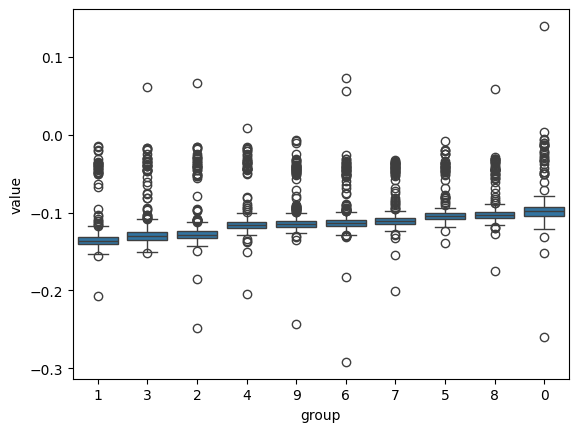

dict_keys(['w1:fp64:idle', 'w1:int128:idle', 'w1:int32:idle', 'w1:int64:idle', 'w1:AVX2:idle', 'w1:fp32:idle', 'w1:SSE2:idle', 'w1:SSE:idle', 'w1:MMX:idle', 'w1:AVX:idle'])
   group    workloadname
0      0    w1:fp64:idle
1      1  w1:int128:idle
2      2   w1:int32:idle
3      3   w1:int64:idle
4      4    w1:AVX2:idle
5      5    w1:fp32:idle
6      6    w1:SSE2:idle
7      7     w1:SSE:idle
8      8     w1:MMX:idle
9      9     w1:AVX:idle
   group  overall_rank    median      mean  orderPositiveCorrelation  \
0      0   3259.794554 -0.098518 -0.093876                         9   
1      1    653.693069 -0.136081 -0.129365                         0   
2      2   1085.259901 -0.128384 -0.121201                         2   
3      3    985.524752 -0.130546 -0.122778                         1   
4      4   1846.272277 -0.116096 -0.110334                         3   
5      5   2937.997525 -0.104131 -0.099563                         7   
6      6   2072.467822 -0.113958 -0.108161      

C:\Users\andyh\AppData\Local\Temp\ipykernel_4356\3602021402.py:89: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(order_with_names)


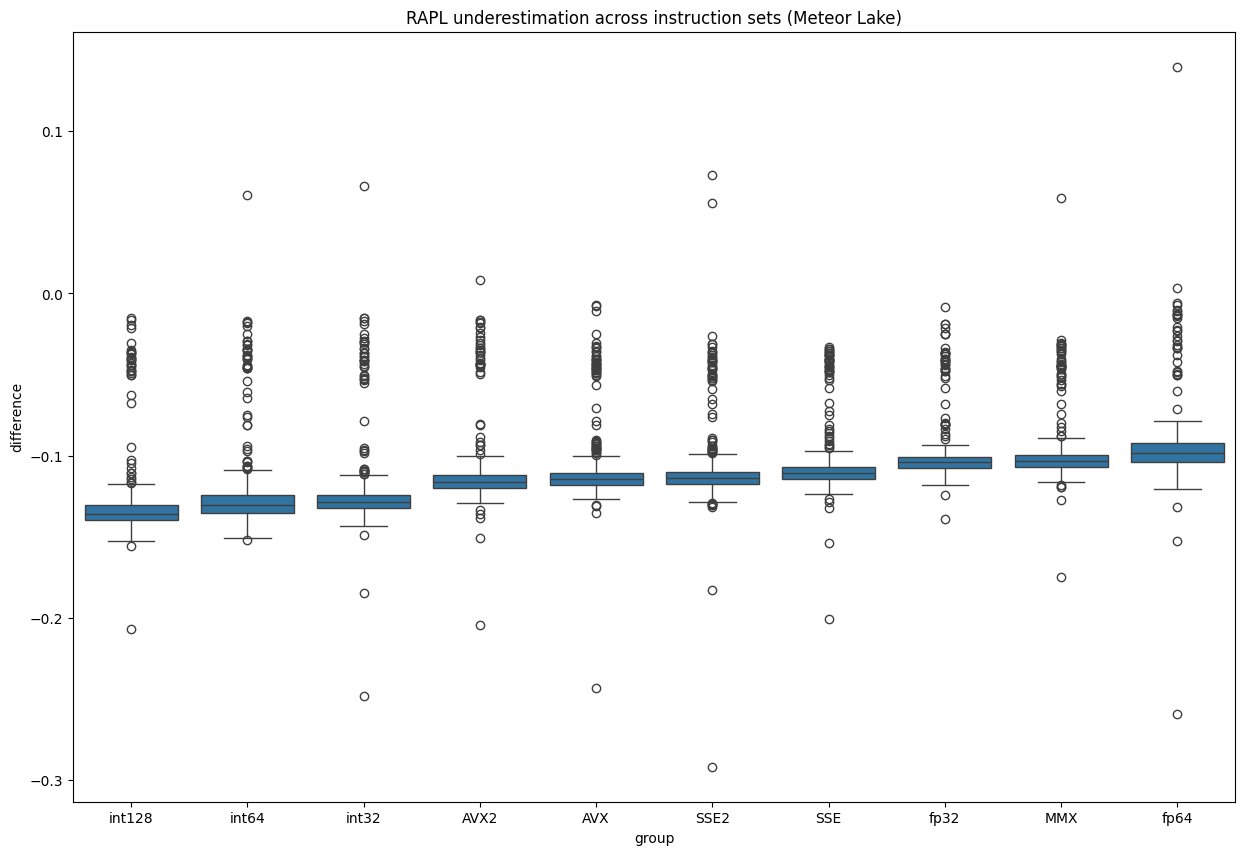

In [16]:
# perform kruskal wallis H test on normalized difference for data collected in each instruction set type workload.
# visualize using box plot 
# performs dunns test to determining if the differences are statistically significant 

writepath = "./"

from scipy.stats import kruskal

kruskal_sample = []
for sample in list(samples_by_workload_kw.values()):
    kruskal_sample.append(sample["diff_normalized"])

# Perform Kruskal-Wallis H-test
result = kruskal(*kruskal_sample)

print(result.statistic)
print(result.pvalue)

df_kruskal_display = pd.DataFrame(columns=["value", "group"])
for i, sample in enumerate(kruskal_sample):
    sample_df = pd.DataFrame()
    sample_df["value"] = sample
    sample_df["group"] = i
    df_kruskal_display = pd.concat([df_kruskal_display, sample_df], axis =0)

from scipy.stats import rankdata
df_kruskal_descriptive = pd.DataFrame()

# Combine your data into a DataFrame
# Assume 'value' is the score and 'group' is the category
df_kruskal_display['overall_rank'] = rankdata(df_kruskal_display['value'])

# Get the ranking of the groups
group_rankings = df_kruskal_display.groupby('group')['overall_rank'].mean().sort_values(ascending=False)
df_kruskal_descriptive = df_kruskal_display.groupby("group")["overall_rank"].mean()
print(group_rankings)

import seaborn as sns
import matplotlib.pyplot as plt

# Sort the groups by their median value to visualize the ranking
order = df_kruskal_display.groupby('group')['value'].median().sort_values().index
df_kruskal_median = pd.DataFrame()
df_kruskal_median["median"] = df_kruskal_display.groupby("group")["value"].median()
df_kruskal_median["mean"] = df_kruskal_display.groupby("group")["value"].mean()

df_kruskal_descriptive = pd.merge(df_kruskal_descriptive, df_kruskal_median, on="group")
print(df_kruskal_median)
#df_kruskal_order = df_kruskal_order.set_index("order")
print(order)
order_by_group = pd.Series(range(len(order)), index=order).sort_index()
df_kruskal_descriptive["orderPositiveCorrelation"] = order_by_group
print(df_kruskal_descriptive)

sns.boxplot(x='group', y='value', data=df_kruskal_display, order=order)
plt.show()
print(samples_by_workload_kw.keys())
df_workload_results = pd.DataFrame()
df_workload_results["workloadname"] = samples_by_workload_kw.keys()
df_workload_results = df_workload_results.reset_index(names="group")
print(df_workload_results)
df_kruskal_descriptive = pd.merge(df_kruskal_descriptive, df_workload_results, on="group")
print(df_kruskal_descriptive)
df_kruskal_descriptive['workloadname'] = df_kruskal_descriptive['workloadname'].apply(lambda x: x.split(':')[1])
print(df_kruskal_descriptive)
df_kruskal_descriptive.to_csv((writepath + "Energy_kruskal_results_descriptive_workloadranking.csv"), index = False)
workload_name_mapping = df_kruskal_descriptive.set_index('group')['workloadname'].to_dict()


import scikit_posthocs as sp

# Assuming 'data' is your list of 10 groups
# We pass the list directly to the dunn test function
print("columns")
print(df_kruskal_display.columns)
p_values = sp.posthoc_dunn(df_kruskal_display,val_col="value", group_col="group", p_adjust='bonferroni')
p_values = p_values.mask(p_values < 0.001, "p < 0.001")

p_values = p_values.rename(index=workload_name_mapping, columns=workload_name_mapping)
print(p_values)
p_values.to_csv((writepath + "Energy_dunn_posthoc_pairwise_workload_comparison.csv"))

# df_kruskal_display["workload name"] = df_kruskal_display["group"].map(workload_name_mapping)
# sns.boxplot(x='group', y='value', data=df_kruskal_display, order=order)
order_with_names = [workload_name_mapping.get(id) for id in order]
plt.figure(figsize=(15, 10))
ax = sns.boxplot(data=df_kruskal_display, x='group', y='value', order=order)
# override the tick labels 
ax.set_xticklabels(order_with_names)
plt.title("RAPL underestimation across instruction sets (Meteor Lake)")
plt.ylabel("difference")
plt.show()




## RQ2: assemble SK-ESD sample matrix (persists `skesd_sample_pc2.pkl`)


In [20]:
print(samples_by_workload_kw.keys())
scottknott_sample = pd.DataFrame()
for key in samples_by_workload_kw.keys():
    scottknott_sample[key.split(':')[1]] = samples_by_workload_kw[key]["diff_normalized"]

scottknott_sample.reset_index(drop=True, inplace=True)

print(scottknott_sample.columns)
print(scottknott_sample.head())

with open("skesd_sample_pc2.pkl", "wb") as file:
    pickle.dump(scottknott_sample, file)


dict_keys(['w1:fp64:idle', 'w1:int128:idle', 'w1:int32:idle', 'w1:int64:idle', 'w1:AVX2:idle', 'w1:fp32:idle', 'w1:SSE2:idle', 'w1:SSE:idle', 'w1:MMX:idle', 'w1:AVX:idle'])
Index(['fp64', 'int128', 'int32', 'int64', 'AVX2', 'fp32', 'SSE2', 'SSE',
       'MMX', 'AVX'],
      dtype='object')
       fp64    int128     int32     int64      AVX2      fp32      SSE2  \
0 -0.095365 -0.138294 -0.138968 -0.133545 -0.125065 -0.112552 -0.124613   
1 -0.091151 -0.128004 -0.123597 -0.134936 -0.112364 -0.100342 -0.120361   
2 -0.098237 -0.126862 -0.118434 -0.132750 -0.115440 -0.101880 -0.118246   
3 -0.089102 -0.128326 -0.127810 -0.129132 -0.109076 -0.109283 -0.115780   
4 -0.085796 -0.133564 -0.115901 -0.136557 -0.114070 -0.098940 -0.131741   

        SSE       MMX       AVX  
0 -0.116688 -0.112322 -0.126530  
1 -0.105864 -0.107684 -0.119557  
2 -0.116037 -0.106423 -0.116540  
3 -0.105622 -0.109178 -0.116935  
4 -0.113432 -0.107231 -0.115119  


## RQ2: Scott-Knott ESD


In [ ]:
# Enhanced np sk esd output, but it throws error so Im keeping the old one around just in case.

import pandas as pd
import rpy2.robjects as robjects
from rpy2.robjects import pandas2ri, conversion, default_converter
from rpy2.robjects.packages import importr

# 1. Import the R library
sk_esd_pkg = importr('ScottKnottESD')

# Remove objects from previous runs 
robjects.r('rm(list = ls(all.names = TRUE))') 

# Assign your dataframe to an R variable named 'r_df'
with robjects.conversion.localconverter(robjects.default_converter + pandas2ri.converter):
    robjects.r.assign("r_df", scottknott_sample)

# Run everything via R strings (Now with ggplot2)
robjects.r('''
    library(ScottKnottESD)
    library(ggplot2)
    library(svglite)
    
    # 1. Run the Scott-Knott ESD test
    sk <- sk_esd(r_df, non.parametric=TRUE)
    
    # --- GGPLOT2 REMAKE SECTION ---
    # Extract the ranking results into a clean R dataframe for ggplot
    plot_data <- data.frame(
        Group = names(sk$groups),
        Rank  = as.factor(sk$groups)
    )
    
    # Merge with the actual raw data to get distribution values for boxplots
    # Melt/reshape the original data frame into a long format
    raw_long <- stack(r_df)
    names(raw_long) <- c("Value", "Group")
    
    # Combine the raw values with their statistical Scott-Knott ranks
    gg_df <- merge(raw_long, plot_data, by="Group")
    
    # Generate the modern ggplot2 graph
    gg <- ggplot(gg_df, aes(x = reorder(Group, Value, FUN = median), y = Value, fill = Rank)) +
        geom_boxplot(alpha = 0.7, outlier.size = 2) +
        theme_minimal(base_size = 14) +
        scale_fill_brewer(palette = "Set2") + # Distinct colors for different ranks
        labs(
            title = "Scott-Knott ESD Grouping Results",
            subtitle = "Groups sharing a color are statistically identical",
            x = "Treatments / Groups",
            y = "Values",
            fill = "Stat Rank"
        ) +
        theme(
            plot.title = element_text(face = "bold", hjust = 0.5),
            plot.subtitle = element_text(hjust = 0.5, color = "darkgray"),
            axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1) # Tilt labels if they overlap
        )
    
    # Save the ggplot using ggsave (superior to png() for ggplot objects)
    ggsave("scott_knott_ggplot.png", plot = gg, width = 8, height = 6, dpi = 300)
    ggsave("scott_knott_plot.pdf", plot = gg, width = 8, height = 6)
    ggsave("scott_knott_plot.svg", plot = gg, width = 8, height = 6)
    # ------------------------------
           
    # 2. CAPTURE STATISTICS
    anova_summary <- capture.output(summary(sk$av))
    group_summary <- capture.output(print(sk$groups))

    # 3. SAVE STATS TO       
    png("scott_knott_stats.png", width=700, height=500)
    plot.new()
           
    full_output <- c("--- ANOVA Table ---", anova_summary, "", "--- Scott-Knott Grouping ---", group_summary)
    
    text(x=0, y=1, labels=paste(full_output, collapse="\n"), 
         adj=c(0,1), family="mono", cex=0.9)
    
    dev.off()     
''')

# Pull it from R
sk_list_vector = robjects.r['sk']

# Convert to a standard Python dictionary
with conversion.localconverter(default_converter + pandas2ri.converter):
    # This maps the R names to the Python-converted values
    sk_results_dict = dict(zip(sk_list_vector.names, list(sk_list_vector)))

print(sk_results_dict.keys())

# Access the results
print("--- Scott-Knott ESD Rankings ---")

# SK_ESD RESULT INFORMATION
# av = anova results
# groups = group results
# nms = names
# ord = order
# m.inf = means information
# sig.level = alpha value used in test
print(sk_results_dict.keys())
for key in sk_results_dict.keys(): 
    print(f"Name: {key} ==============================================================")
    obj = sk_results_dict[key]
    if (type(obj) == "arraylike"):
        print(obj)
    else:
        print(list(obj))

print(sk_results_dict["groups"])

Error importing in API mode: ImportError('On Windows, cffi mode "ANY" is only "ABI".')
Trying to import in ABI mode.
R callback write-console: Use suppressPackageStartupMessages() to eliminate package startup
messages
  
R callback write-console: In addition:   
R callback write-console: Warning messages:
  
R callback write-console: 1: package 'ggplot2' was built under R version 4.4.3 
  
R callback write-console: 2: package 'svglite' was built under R version 4.4.3 
  


dict_keys(['av', 'groups', 'nms', 'ord', 'm.inf', 'sig.level'])
--- Scott-Knott ESD Rankings ---
dict_keys(['av', 'groups', 'nms', 'ord', 'm.inf', 'sig.level'])
Name: av ==============================================================
[array([-0.09387626, -0.03548906, -0.02732514, -0.02890158, -0.01645763,
       -0.00568713, -0.01428426, -0.01197976, -0.00472557, -0.01431776]), array([-0.00148858,  0.00272541, -0.00436065, ...,  0.06297559,
        0.06764993,  0.10095495]), array([ 6.97855535, -0.41467764, -0.28957717, ...,  0.06331986,
        0.0679942 ,  0.10129922]), array([10], dtype=int32), array([-0.09387626, -0.09387626, -0.09387626, ..., -0.10819402,
       -0.10819402, -0.10819402]), array([0, 1, 1, 1, 1, 1, 1, 1, 1, 1], dtype=int32), <rpy2.rlike.container.NamedList object at 0x0000023D83A99BB0>, array([4030], dtype=int32), <rpy2.rlike.container.NamedList object at 0x0000023D83A99760>, <rpy2.rlike.container.NamedList object at 0x0000023D83A99460>, Rlang( aov(formula = value ~